In [376]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# For importing universal scripts
import sys
import os
# Go up two levels from the subfolder
sys.path.append(os.path.abspath("/.."))
from indicators_returns import final_df #Universal script for indicator set and actuals
import importlib
import indicators_returns
importlib.reload(indicators_returns)
from indicators_returns import final_df
import gc
from sklearn.metrics import (fbeta_score, accuracy_score, f1_score, 
                             confusion_matrix, balanced_accuracy_score, recall_score, matthews_corrcoef, precision_score)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, StratifiedKFold
from xgboost import XGBClassifier
import math
import pickle

tags = pd.read_csv('../Indicator_Selection_Pipeline/Finalization/tags_cons.csv') 

def extract(ticker, returns, lb, cat_cols_all, windows=[10, 25]):

    import os
    # point this at an existing directory in your project
    os.chdir('/Users/brettchase/Documents/Fracturion/Feature_Set_Construction_Testing')
    
    df = final_df(ticker, returns, lb)
    df = df.iloc[:-101].replace([np.inf, -np.inf], 0)#

    df = df.sort_index(ascending=True)
    # Exponential Moving Average
    ema_cols = {
        f"{col}_EMA{w}": df[col].ewm(span=w, adjust=False).mean()
        for w in windows
        for col in cat_cols_all
    }
    # 3) merge them back into one dict
    new_cols = {**ema_cols}

    # 4) concatenate onto your original df
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)    
    df = df.sort_index(ascending=False)
    
    return df

lb = 8
returns = [2, 3, 4, 5, 8, 10, 15, 20]
raw_all = tags['Indicator'][tags['Type'] == 'Raw'].tolist()
df = extract('QQQ', returns, lb, raw_all, windows=[10,25])

# By category × velocity
raw_duration_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_duration_slow_10 = [f"{col}_EMA10" for col in raw_duration_slow]
raw_duration_slow_25 = [f"{col}_EMA25" for col in raw_duration_slow]

raw_duration_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_duration_moderate_10 = [f"{col}_EMA10" for col in raw_duration_moderate]
raw_duration_moderate_25 = [f"{col}_EMA25" for col in raw_duration_moderate]

raw_duration_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_duration_fast_10 = [f"{col}_EMA10" for col in raw_duration_fast]
raw_duration_fast_25 = [f"{col}_EMA25" for col in raw_duration_fast]

raw_trend_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_trend_slow_10 = [f"{col}_EMA10" for col in raw_trend_slow]
raw_trend_slow_25 = [f"{col}_EMA25" for col in raw_trend_slow]

raw_trend_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_trend_moderate_10 = [f"{col}_EMA10" for col in raw_trend_moderate]
raw_trend_moderate_25 = [f"{col}_EMA25" for col in raw_trend_moderate]

raw_trend_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_trend_fast_10 = [f"{col}_EMA10" for col in raw_trend_fast]
raw_trend_fast_25 = [f"{col}_EMA25" for col in raw_trend_fast]

raw_trend_ratio_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_trend_ratio_slow_10 = [f"{col}_EMA10" for col in raw_trend_ratio_slow]
raw_trend_ratio_slow_25 = [f"{col}_EMA25" for col in raw_trend_ratio_slow]

raw_trend_ratio_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_trend_ratio_moderate_10 = [f"{col}_EMA10" for col in raw_trend_ratio_moderate]
raw_trend_ratio_moderate_25 = [f"{col}_EMA25" for col in raw_trend_ratio_moderate]

raw_trend_ratio_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_trend_ratio_fast_10 = [f"{col}_EMA10" for col in raw_trend_ratio_fast]
raw_trend_ratio_fast_25 = [f"{col}_EMA25" for col in raw_trend_ratio_fast]

raw_volatility_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_volatility_slow_10 = [f"{col}_EMA10" for col in raw_volatility_slow]
raw_volatility_slow_25 = [f"{col}_EMA25" for col in raw_volatility_slow]

raw_volatility_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_volatility_moderate_10 = [f"{col}_EMA10" for col in raw_volatility_moderate]
raw_volatility_moderate_25 = [f"{col}_EMA25" for col in raw_volatility_moderate]

raw_volatility_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_volatility_fast_10 = [f"{col}_EMA10" for col in raw_volatility_fast]
raw_volatility_fast_25 = [f"{col}_EMA25" for col in raw_volatility_fast]

raw_momentum_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_momentum_slow_10 = [f"{col}_EMA10" for col in raw_momentum_slow]
raw_momentum_slow_25 = [f"{col}_EMA25" for col in raw_momentum_slow]

raw_momentum_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_momentum_moderate_10 = [f"{col}_EMA10" for col in raw_momentum_moderate]
raw_momentum_moderate_25 = [f"{col}_EMA25" for col in raw_momentum_moderate]

raw_momentum_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_momentum_fast_10 = [f"{col}_EMA10" for col in raw_momentum_fast]
raw_momentum_fast_25 = [f"{col}_EMA25" for col in raw_momentum_fast]

# Start with must include columns (slope)

In [367]:
def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            print(f"  Threshold {thresh}: {metric_values}")
    
def optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False):
    
    def train_and_evaluate(model, param_grid, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh):
        
        # Create a Stratified K-Fold object
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Perform Random Search
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,  # Corrected from param_grid to param_distributions
            scoring=opt,
            cv=stratified_kfold,
            n_jobs=-1,
            n_iter=40,  # Adjust this based on how many random samples you want to try
            random_state=42  # Ensures reproducibility
        )

        random_search.fit(X_train, y_train, eval_set=[(X_val, y_val)],
        verbose=False)
        best_model = random_search.best_estimator_
        # Predict probabilities
        y_prob = best_model.predict_proba(X_test)
        postot = y_test.sum()
        negtot = len(y_test) - y_test.sum()

        # Evaluate metrics for each threshold
        metrics = {}
        for t in thresh:
            y_pred_thresh = (y_prob[:, 1] > t).astype(int)
            y_pred_thresh[y_prob[:, 0] > t] = 0
            filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)

            if filtered_indices.sum() > 0:
                y_test_valid = y_test[filtered_indices]
                y_pred_valid = y_pred_thresh[filtered_indices]
                posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                poscnt = sum(y_pred_valid == 1)
                negcnt = sum(y_pred_valid == 0)
                posrec = round(posprec * poscnt / postot, 2)
                negrec = round(negprec * negcnt / negtot, 2)
                metrics[t] = {
                    'TT_Len': len(df_indicators),
                    "PosTot": postot,  
                    "NegTot": negtot,  
                    "PosRec": posrec,
                    'PosPrec': posprec,  
                    "NegRec": negrec,
                    'NegPrec': negprec,  
                    'PosFb': round((3*posprec*posrec)/((2*posrec)+(1*posprec)),3),
                    'NegFb': round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),
                }

        del random_search
        gc.collect()

        return metrics, best_model

    if arch == 'shallow':
        # Shallow
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [200, 300],
            'max_depth': [5, 7], 
            'learning_rate': [0.01],
            'subsample': [0.65],
            'colsample_bytree': [0.6], 
            'gamma': [0.2, 0.4],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [12, 15],
            'early_stopping_rounds': [10]
        }

    elif arch == 'moderate':

        # Moderate
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [300, 400],
            'max_depth': [7, 9], 
            'learning_rate': [0.01],
            'subsample': [0.65, .75],
            'colsample_bytree': [0.6, 0.7], 
            'gamma': [0.2, 0.3],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [9, 11],
            'early_stopping_rounds': [8]
        }

    else:

        # Deep
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [200, 300, 400],
            'max_depth': [6, 9, 11], 
            'learning_rate': [0.01],
            'subsample': [0.75, .85],
            'colsample_bytree': [0.75, 0.85], 
            'gamma': [0.1, 0.2],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [7, 9],
            'early_stopping_rounds': [10]
        }
        
    X_test = df_indicators.iloc[:perf_size].copy()
    y_test = df_predict.iloc[:perf_size].copy()
    df_indicators = df_indicators.iloc[test_size:].copy()
    df_predict = df_predict.iloc[test_size:].copy()

    X_val = df_indicators.iloc[:val_size].copy()
    y_val = df_predict.iloc[:val_size].copy()
    X_train = df_indicators.iloc[val_size:].copy()
    y_train = df_predict.iloc[val_size:].copy()

    # Train and evaluate models
    xg_metrics, best_xg_model = train_and_evaluate(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh)
    #record_validation_metrics(xg_metrics, arch='shallow', horizon=r, model_name=name)
    #savearch(best_xg_model, r, name, arch)
    metrics = list(xg_metrics.values())[0]
    pscore = metrics.get('PosFb', 0)
    nscore = metrics.get('NegFb', 0)

    #if pscore > .6 and nscore > .6:
    print_metrics(xg_metrics)

    if return_metrics:
        return xg_metrics, best_xg_model
    else:
        #print_metrics(xg_metrics)
        return best_xg_model
    
def save(best_model, days, model, ticker, arch):
    
    directory = f'../Models/Ensemble_{ticker}'  # Saves to the current working directory
    os.makedirs(directory, exist_ok=True)
    
    with open(os.path.join(directory, str(model)+'_xgboost_'+str(days)+str(arch)+'.pkl'), 'wb') as file_object:
        pickle.dump(best_model, file_object)

    print('Models Saved for '+(ticker)+'_'+str(model)+' '+str(days)+'_'+' Returns')

# Velocity x Category Combo Groupings

In [369]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(invalid='ignore', divide='ignore')
tickers = ['QQQ']#['NVDA', "AAPL", "MSFT", "TSLA", "AMZN", "AVGO", "META", "GOOGL", "COST", "NFLX"]
thresh = [.5]
arch_types = ['deep']
results = []
returns = [2, 3, 4, 5, 8, 10, 15, 20]

selected_combos = {
    "h_2": {
    'raw_trend_fast+raw_trend_ratio_slow_25': raw_trend_fast+raw_trend_ratio_slow_25,
    'raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10': raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10,
    'raw_trend_ratio_moderate_25+raw_volatility_moderate_25': raw_trend_ratio_moderate_25+raw_volatility_moderate_25,
    'raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10': raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10,
    'raw_trend_ratio_moderate_10+raw_momentum_moderate_25': raw_trend_ratio_moderate_10+raw_momentum_moderate_25,
    },
    "h_3": {
    'raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast': raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast,
    'raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate': raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate,
    'raw_duration_fast+raw_trend_slow': raw_duration_fast+raw_trend_slow,
    'raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25': raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25,
    'raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow': raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow,
    },
    "h_4": {
    'raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25': raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25,
    'raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow': raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow,
    'raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10': raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10,
    'raw_duration_moderate_10+raw_volatility_moderate_25': raw_duration_moderate_10+raw_volatility_moderate_25,
    'raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10': raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10,
    },
    "h_5": {
    'raw_duration_slow_10+raw_trend_ratio_fast_25': raw_duration_slow_10+raw_trend_ratio_fast_25,
    'raw_duration_slow+raw_trend_ratio_fast_25': raw_duration_slow+raw_trend_ratio_fast_25,
    'raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10': raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10,
    'raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast': raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast,
    'raw_trend_moderate_25+raw_trend_ratio_moderate_25': raw_trend_moderate_25+raw_trend_ratio_moderate_25,
    },
    "h_8": {
    'raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25': raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25,
    'raw_trend_fast_10+raw_trend_ratio_slow_25': raw_trend_fast_10+raw_trend_ratio_slow_25,
    'raw_trend_ratio_slow_10+raw_momentum_moderate': raw_trend_ratio_slow_10+raw_momentum_moderate,
    'raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25': raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25,
    'raw_trend_slow+raw_trend_slow_25': raw_trend_slow+raw_trend_slow_25,
    },
    "h_10": {
    'raw_trend_ratio_slow_25+raw_volatility_moderate_25': raw_trend_ratio_slow_25+raw_volatility_moderate_25,
    'raw_duration_moderate+raw_trend_slow': raw_duration_moderate+raw_trend_slow,
    'raw_duration_moderate_25+raw_trend_slow_10': raw_duration_moderate_25+raw_trend_slow_10,
    'raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10': raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10,
    'raw_trend_ratio_slow_10+raw_momentum_moderate_10': raw_trend_ratio_slow_10+raw_momentum_moderate_10,
    },
    "h_15": {
    'raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast': raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast,
    'raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25': raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25,
    'raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10': raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10,
    'raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25': raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25,
    'raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate': raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate,
    },
    "h_20": {
    'raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10': raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10,
    'raw_trend_ratio_moderate_25+raw_momentum_moderate_25': raw_trend_ratio_moderate_25+raw_momentum_moderate_25,
    'raw_trend_slow_25+raw_momentum_moderate_10': raw_trend_slow_25+raw_momentum_moderate_10,
    'raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25': raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25,
    'raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25': raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25,
    },
}

def get_model_set(horizon):
    if horizon in [2]:
        key = "h_2"
    elif horizon in [3]:
        key = "h_3"
    elif horizon in [4]:
        key = "h_4"
    elif horizon in [5]:
        key = "h_5" 
    elif horizon in [8]:
        key = "h_8"
    elif horizon in [10]:
        key = "h_10"
    elif horizon in [15]:
        key = "h_15"
    elif horizon in [20]:
        key = "h_20"
    else:
        raise ValueError(f"Unsupported horizon: {horizon}")
    
    return selected_combos[key]

for ticker in tickers:
    
    df = extract(ticker, returns, lb, raw_all, windows=[10,25])

    for r in returns:
            
        selected_models = get_model_set(r)
        
        # all index-combos of length r
        for name, cols in selected_models.items():

            df_ph = df.copy()
            df_ph = df_ph.iloc[r:].copy()
            return_col = f"Return_{r}"
            return_perc_col = f"Return%_{r}"
            model_key = f"QQQ_{r}"

            rets = df_ph[return_perc_col].copy()
            # Split into negative and positive returns
            neg = rets[rets < 0]
            pos = rets[rets > 0]
            # Calculate dynamic thresholds
            neg_cutoff = neg.nlargest(int(len(neg) * 0.05)).min()  # least negative of top 10% in magnitude
            pos_cutoff = pos.nsmallest(int(len(pos) * 0.05)).max()  # smallest positive of top 10% in magnitude
            
            filtered = df_ph[(df_ph[f'Return%_{r}'] < neg_cutoff) | (df_ph[f'Return%_{r}'] > pos_cutoff)].copy()
            counts = filtered[return_col].value_counts()
            negf = counts.get(0, 0)
            posf = counts.get(1, 1)  # prevent division by zero
            #print(f'{posf} | {negf}')
            scale_pos_weight = negf / posf

            for arch in arch_types:

                # Choose evaluation metric
                opt = 'matthews_corrcoef'

                # Combine features with return column, drop missing
                #cols += ['Close_slope10', 'Close_slope25', 'Close_slope50']
                cols = list(dict.fromkeys(cols))

                used_cols = cols + [return_col]
                df_model = filtered[used_cols].dropna()
                #print(df_ph['Date'].iloc[0])
                
                df_indicators = df_model[cols]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                
                print(f"Results for {name} | {arch} | {ticker}_{r}")
                val_size = 300
                test_size = 100
                perf_size = 100
                #xg_metrics, best_xg_model = optimize_tests(df_indicators, df_predict, thresh, opt, depth, scale_pos_weight, min_child_weight, r, name, arch, date, return_metrics=True)
                best_xg_model = optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False)
                save(best_xg_model, r, name, ticker, arch)
                #metrics = list(xg_metrics.values())[0]
                # build one flat record
                #row = {'name': name, 'lb': lb, 'arch': arch, 'ticker': ticker, 'horizon': r, 'date': date, **metrics}
                #results.append(row)
                print('---------------------------')

Results for raw_trend_fast+raw_trend_ratio_slow_25 | deep | QQQ_2
  Threshold 0.5: {'TT_Len': 1453, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.82, 'PosPrec': 0.73, 'NegRec': 0.56, 'NegPrec': 0.68, 'PosFb': 0.758, 'NegFb': 0.635}
Models Saved for QQQ_raw_trend_fast+raw_trend_ratio_slow_25 2_ Returns
---------------------------
Results for raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10 | deep | QQQ_2
  Threshold 0.5: {'TT_Len': 1453, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.76, 'PosPrec': 0.76, 'NegRec': 0.66, 'NegPrec': 0.66, 'PosFb': 0.76, 'NegFb': 0.66}
Models Saved for QQQ_raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10 2_ Returns
---------------------------
Results for raw_trend_ratio_moderate_25+raw_volatility_moderate_25 | deep | QQQ_2
  Threshold 0.5: {'TT_Len': 1453, 'PosTot': 59, 'NegTot': 41, 'PosRec': 0.79, 'PosPrec': 0.72, 'NegRec': 0.56, 'NegPrec': 0.66, 'PosFb': 0.742, 'NegFb': 0.623}
Models Saved for QQQ_raw_trend_ratio_moderate_25+raw_volatil

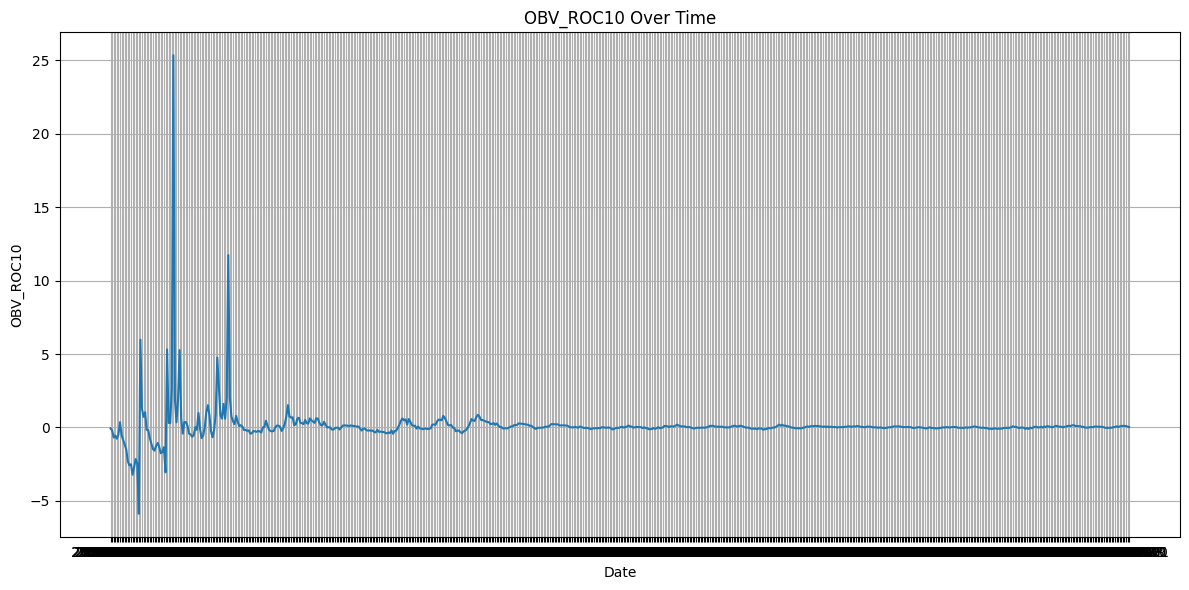

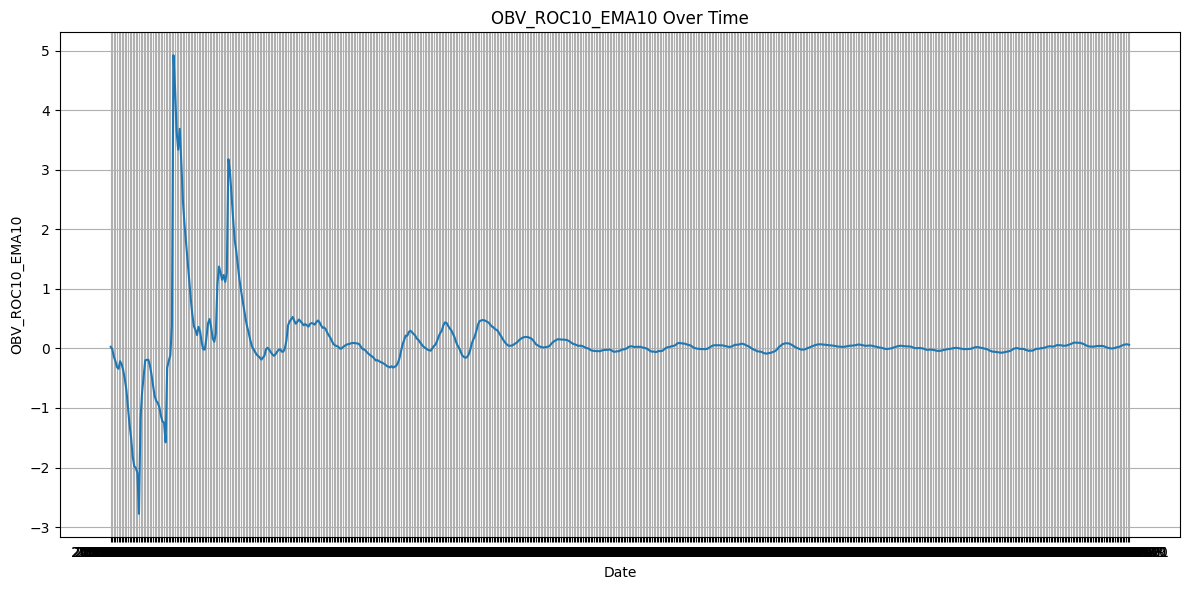

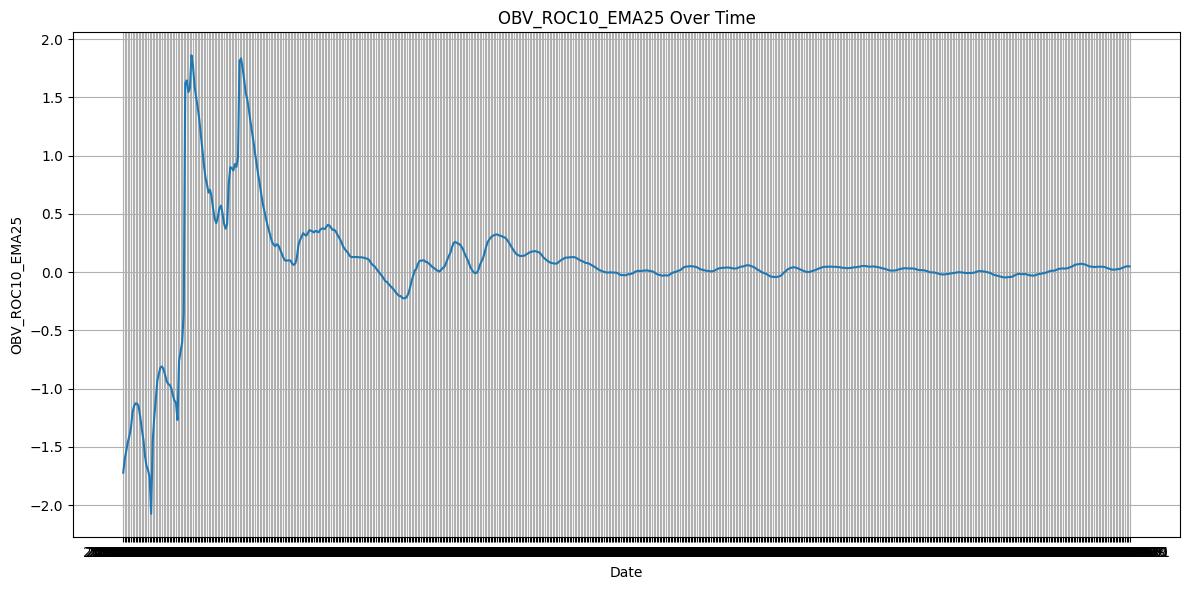

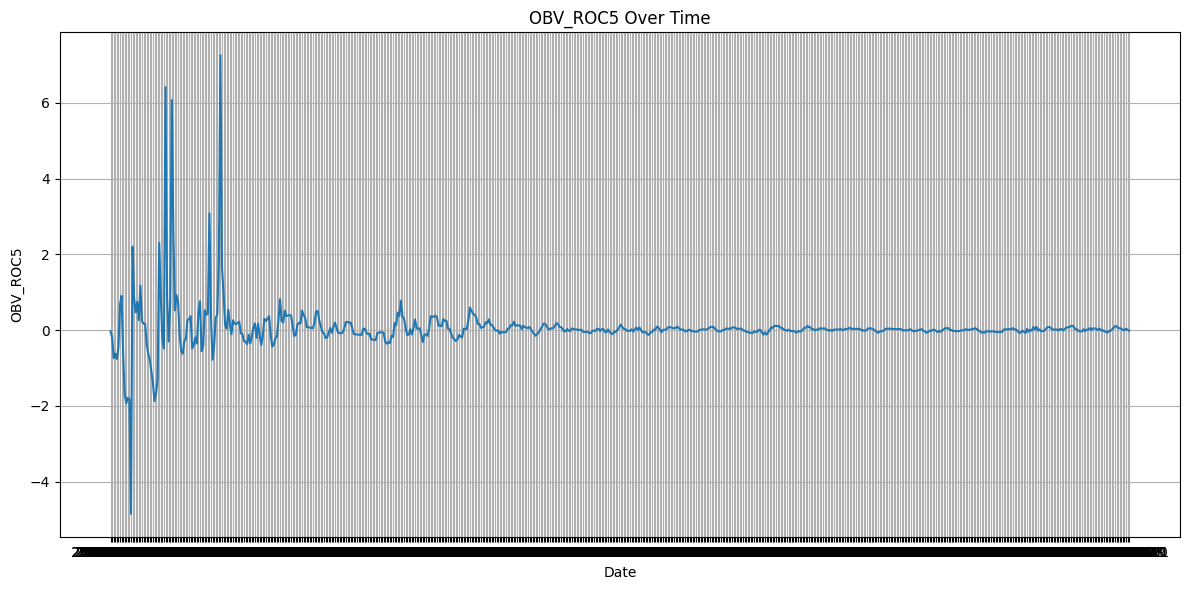

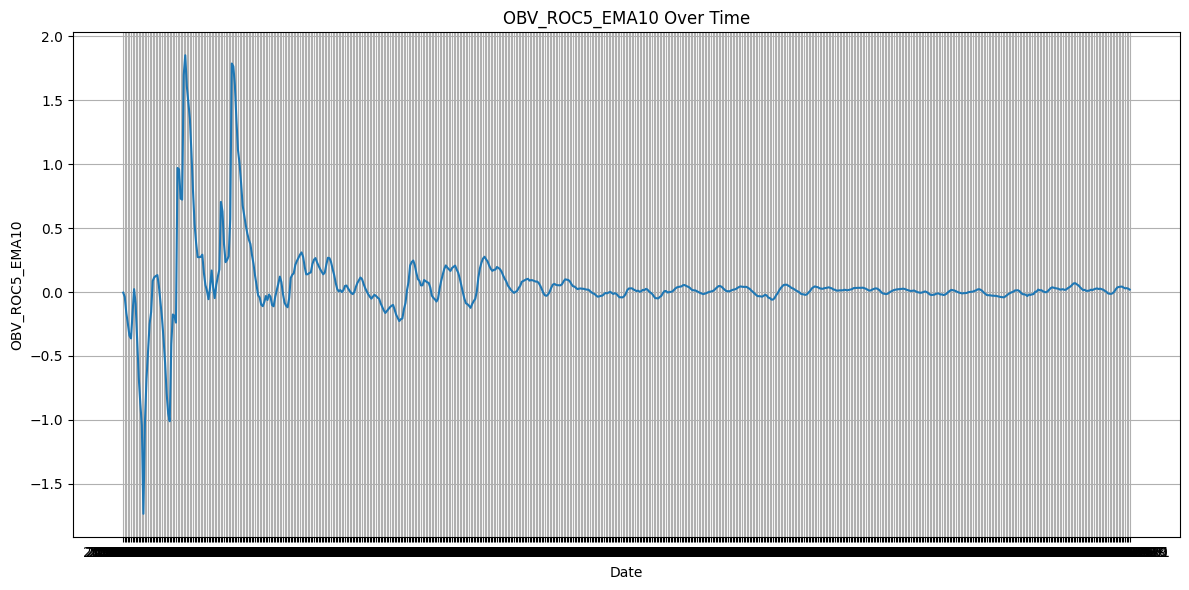

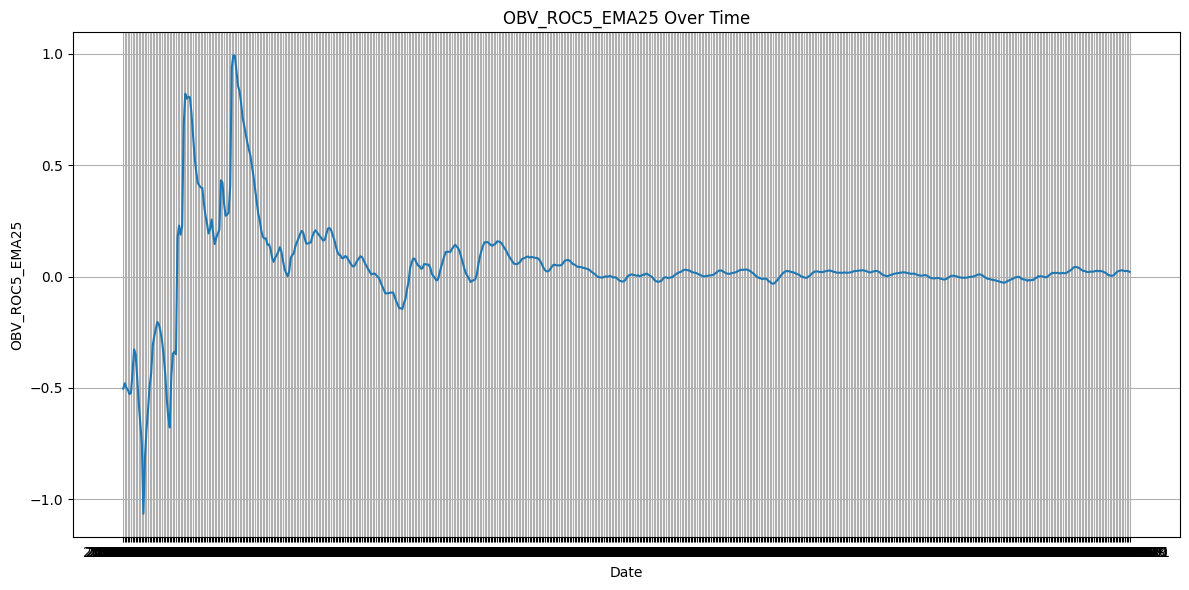

In [262]:
import matplotlib.pyplot as plt
#df = extract('QQQ', returns, lb, raw_all, windows=[10,25])
cols = [
    'VROC_10', 'VROC_10_EMA10', 'VROC_10_EMA25',
    'VROC_5', 'VROC_5_EMA10', 'VROC_5_EMA25',
    'VROC_3', 'VROC_3_EMA10', 'VROC_3_EMA25',
    'OBV_ROC10', 'OBV_ROC10_EMA10', 'OBV_ROC10_EMA25',
    'OBV_ROC5', 'OBV_ROC5_EMA10', 'OBV_ROC5_EMA25',
    'Regime_Category', 'Regime_Category_EMA10', 'Regime_Category_EMA25',
    'VIX_1_change', 'VIX_1_change_EMA10', 'VIX_1_change_EMA25',
    'VIX_5_change', 'VIX_5_change_EMA10', 'VIX_5_change_EMA25',
    'vol_5', 'vol_5_EMA10', 'vol_5_EMA25',
    'Intraday Change', 'Intraday Change_EMA10', 'Intraday Change_EMA25',
    'Vol_Ratio_100', 'Vol_Ratio_100_EMA10', 'Vol_Ratio_100_EMA25',
    'Price_Vol_Ratio_5', 'Price_Vol_Ratio_5_EMA10', 'Price_Vol_Ratio_5_EMA25',
    'ATR_7', 'ATR_7_EMA10', 'ATR_7_EMA25',
    'Vol_Ratio_10', 'Vol_Ratio_10_EMA10', 'Vol_Ratio_10_EMA25',
    'vol_25', 'vol_25_EMA10', 'vol_25_EMA25',
    'vol_10', 'vol_10_EMA10', 'vol_10_EMA25'
]


cols = [
    'OBV_ROC10', 'OBV_ROC10_EMA10', 'OBV_ROC10_EMA25',
    'OBV_ROC5', 'OBV_ROC5_EMA10', 'OBV_ROC5_EMA25',
]
for col in cols:
    try:
        plt.figure(figsize=(12, 6))
        plt.plot(df['Date'].iloc[:650].sort_index(ascending=True), df[col].iloc[:650].sort_index(ascending=True))
        plt.xlabel('Date')
        plt.ylabel(f'{col}')
        plt.title(f'{col} Over Time')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except KeyError:
        continue

In [377]:
model_dir = f'../Models/Ensemble_{ticker}'
thresh = [.51]

# Thresholds for prediction decision
upper = thresh[0]
lower = 1 - upper

# Placeholder for final predictions
combined_predictions = {}
df = extract(ticker, returns, lb, raw_all, windows=[10,25])

# Iterate through each return horizon
for r in returns:

    return_col = f"Return_{r}"

    df_ph = df.copy()

    # Create base prediction matrix with Date and Close
    pred_matrix = df_ph[['Date', 'Close']].copy()

    for arch in arch_types:
    
        selected_models = get_model_set(r)
            
        # all index-combos of length r
        for name, cols in selected_models.items():

            df_features = df_ph[cols].copy()
            df_features = df_features.replace([np.inf, -np.inf], 0)

            # XGBoost prediction
            xgb_path = os.path.join(model_dir, f"{name}_xgboost_{r}{arch}.pkl")
            if os.path.exists(xgb_path):
                with open(xgb_path, 'rb') as f:
                    model_xgb = pickle.load(f)
                prob_xgb = model_xgb.predict_proba(df_features)[:, 1]
                col_name_xgb = f"{name}_xgb_{r}{arch}"
                pred_matrix[col_name_xgb] = np.where(
                    prob_xgb > upper, prob_xgb,
                    np.where(prob_xgb < lower, prob_xgb - 1, 0)
                )

            # Final summed prediction across models
            pred_cols = [col for col in pred_matrix.columns if col not in ['Date', 'Close'] and not col.startswith('sum_')]
            pred_matrix[f"sum_{r}"] = pred_matrix[pred_cols].sum(axis=1)

            combined_predictions[r] = pred_matrix

final_df = None

for r, df_preds in combined_predictions.items():
    cols_to_merge = [col for col in df_preds.columns if col not in ['Date', 'Close']]
    df_preds_renamed = df_preds[['Date', 'Close'] + cols_to_merge].copy()

    if final_df is None:
        final_df = df_preds_renamed
    else:
        final_df = pd.merge(final_df, df_preds_renamed, on=['Date', 'Close'], how='outer')

sub_model_df = final_df.copy()
sub_model_df[['Date', 'Close', 'sum_2', 'sum_3', 'sum_4', 'sum_5', 'sum_8', 'sum_10',
              'sum_15', 'sum_20']].sort_index(ascending=False).head(30).round(3)

,Date,Close,sum_2,sum_3,sum_4,sum_5,sum_8,sum_10,sum_15,sum_20
1758,2025-07-18,561.260,1.107,2.183,1.152,2.719,2.762,1.595,0.682,-0.874
1757,2025-07-17,561.800,1.678,2.753,1.731,2.192,2.836,1.645,0.680,-0.875
1756,2025-07-16,557.290,2.217,2.771,1.819,2.776,2.875,1.668,0.736,-0.400
1755,2025-07-15,556.720,1.691,2.261,1.705,2.749,2.951,1.695,0.755,-0.359
1754,2025-07-14,556.210,2.728,2.711,2.281,2.738,2.978,1.739,1.866,0.151
1753,2025-07-11,554.200,2.743,2.690,2.293,2.773,2.997,1.768,2.055,-0.193
1752,2025-07-10,555.450,2.786,2.739,2.268,2.747,3.044,2.359,2.060,0.357
1751,2025-07-09,556.250,2.760,2.703,2.268,2.750,3.058,2.915,2.276,0.952
1750,2025-07-08,552.340,2.787,2.291,2.915,2.850,3.101,2.967,3.445,2.164
1749,2025-07-07,552.030,2.279,2.822,2.901,2.928,3.103,2.966,3.472,2.198


In [161]:
# BEFORE any loops:
feature_importance_records = []

for r in returns:
    return_col = f"Return_{r}"
    df_ph = df.copy()
    pred_matrix = df_ph[['Date','Close']].copy()

    for arch in arch_types:
        selected_models = get_model_set(r)
        
        for name, cols in selected_models.items():
            # prepare features
            df_features = df_ph[cols].replace([np.inf, -np.inf], 0)

            # load model if it exists
            xgb_path = os.path.join(model_dir, f"{name}_xgboost_{r}.pkl")
            if not os.path.exists(xgb_path):
                continue
            with open(xgb_path,'rb') as f:
                model_xgb = pickle.load(f)

            # 1) record the top-5 importances
            importances = model_xgb.feature_importances_
            feat_imp_pairs = list(zip(cols, importances))
            for feature, imp in sorted(feat_imp_pairs, key=lambda x: x[1], reverse=True)[:5]:
                feature_importance_records.append({
                    'horizon':   r,
                    'arch':      arch,
                    'model':     name,
                    'feature':   feature,
                    'importance': imp
                })

            # 2) your existing prediction code
            prob_xgb     = model_xgb.predict_proba(df_features)[:,1]
            col_name_xgb = f"{name}_xgb_{r}{arch}"
            pred_matrix[col_name_xgb] = np.where(
                prob_xgb > upper, prob_xgb,
                np.where(prob_xgb < lower, prob_xgb - 1, 0)
            )

# AFTER all loops:
fi_df = pd.DataFrame(feature_importance_records)

In [378]:
def performance_metrics(metrics_df, returns):

    metrics_df = metrics_df.sort_index(ascending=True)

    def add_column_based_on_future_value(df, days):

        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']

        if days >= 100:
            df[f'Return_{days}'] = np.where(
                future_return > 0.001, 1,
                np.where(future_return < -0.001, 0, np.nan)
            )
        else:
            df[f'Return_{days}'] = (future_return > 0).astype(int)

        return df

    # Apply return logic for each target horizon
    for r in returns: 
        new_df = add_column_based_on_future_value(metrics_df, r)

    return new_df

performance_df = performance_metrics(sub_model_df.round(3), returns)

horizons = returns
# Dictionary to store the filtered DataFrames
horizon_dfs = {}

# Loop through each horizon
for h in horizons:
    # Collect relevant columns
    cols = ['Date', 'Close'] + [
        col for col in performance_df.columns 
        if col.endswith(f'_xgb_{h}deep') or col.endswith(f'_xgb_{h}shallow') or col == f'sum_{h}' or col == f'Return_{h}'
    ]
    
    # Create and store the filtered DataFrame
    horizon_dfs[h] = performance_df[cols].copy()

def convert_signed_to_prob(p):
    return p if p >= 0 else 1 + p

In [111]:
import pandas as pd

# never wrap a wide DataFrame across multiple lines
pd.set_option('display.expand_frame_repr', False)
# show all columns
pd.set_option('display.max_columns', None)
# pretend the display is super wide
pd.set_option('display.width', 10000)
       

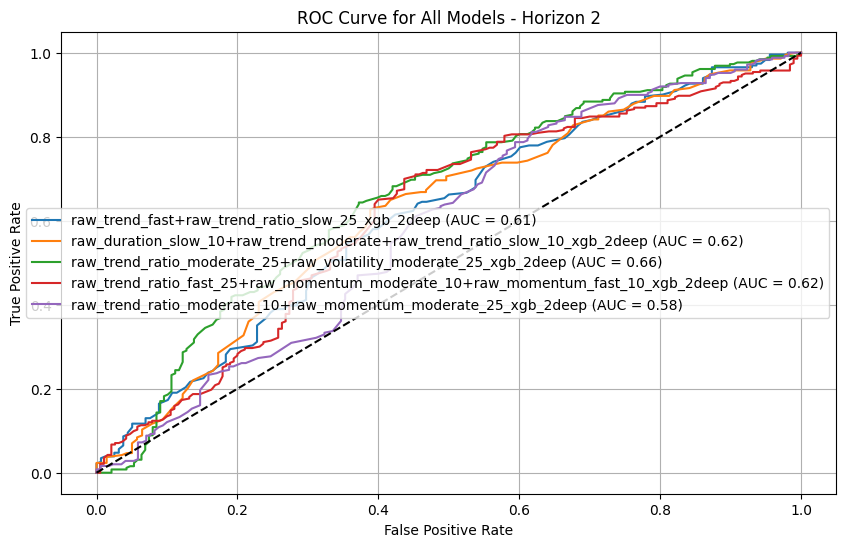

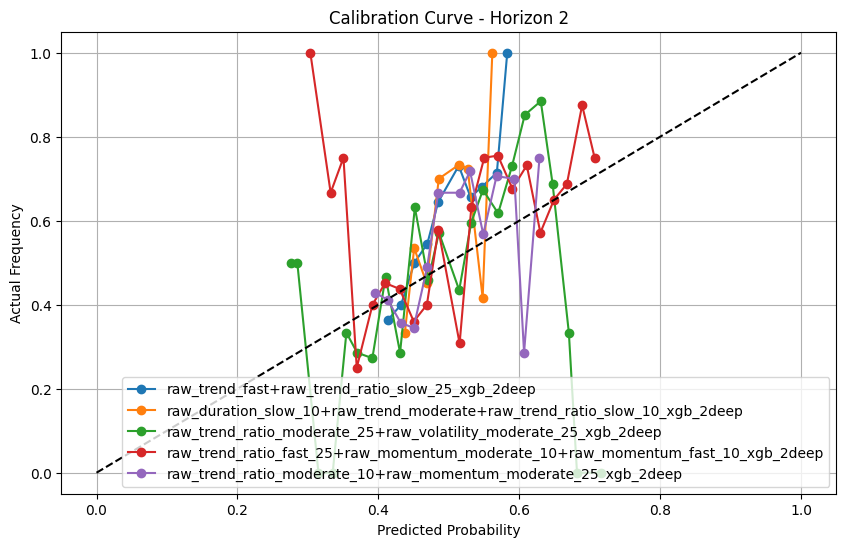

                                                                             model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn   fn
0                                 raw_trend_fast+raw_trend_ratio_slow_25_xgb_2deep      296      204   68.9%   47.4%  111  50  108  120
1        raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10_xgb_2deep      296      204   71.3%   47.3%  107  43   96  107
2                 raw_trend_ratio_moderate_25+raw_volatility_moderate_25_xgb_2deep      296      204   66.5%   57.0%  187  94   94   71
3  raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10_xgb_2deep      296      204   68.0%   55.1%  208  98   92   75
4                   raw_trend_ratio_moderate_10+raw_momentum_moderate_25_xgb_2deep      296      204   65.7%   54.1%  188  98   72   61
 


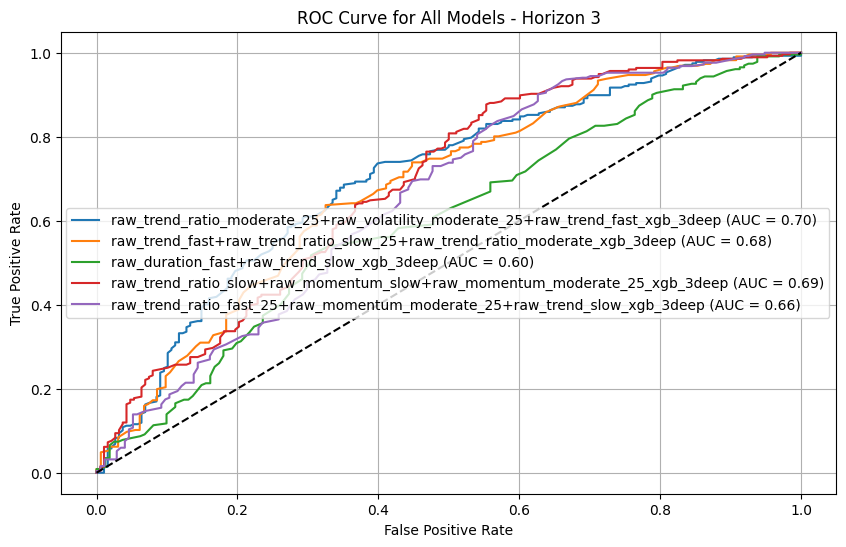

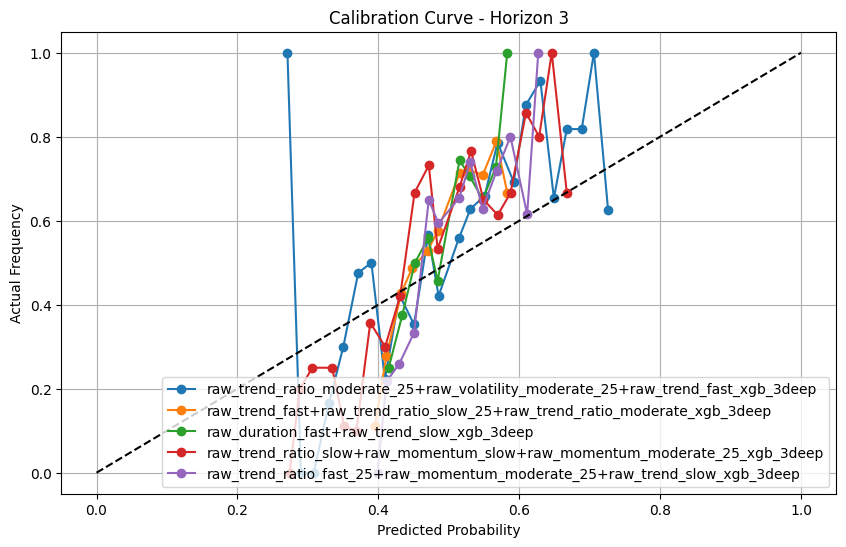

                                                                             model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn   fn
0  raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast_xgb_3deep      297      203   71.9%   60.0%  205  80  108   72
1        raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate_xgb_3deep      297      203   72.3%   54.6%  133  51  112   93
2                                       raw_duration_fast+raw_trend_slow_xgb_3deep      297      203   70.7%   50.0%  118  49  112  112
3        raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25_xgb_3deep      297      203   71.4%   54.2%  177  71  117   99
4        raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow_xgb_3deep      297      203   68.8%   54.2%  170  77   97   82
 


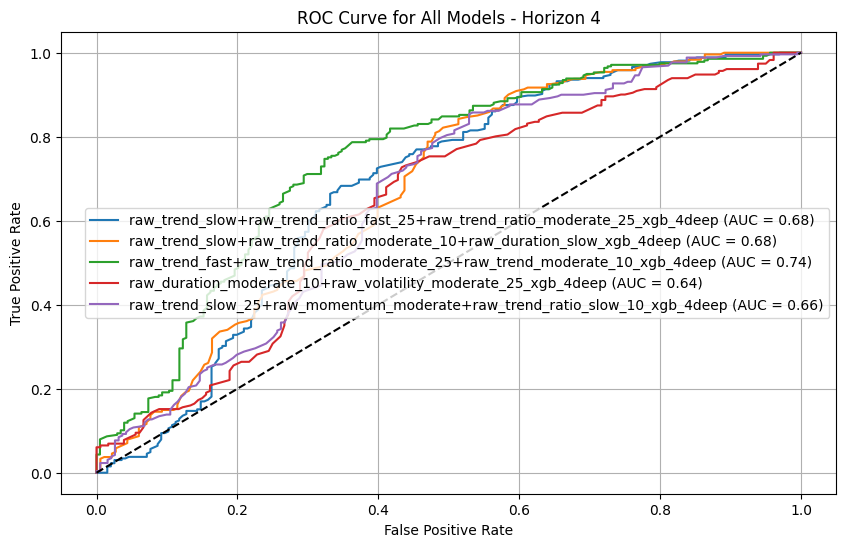

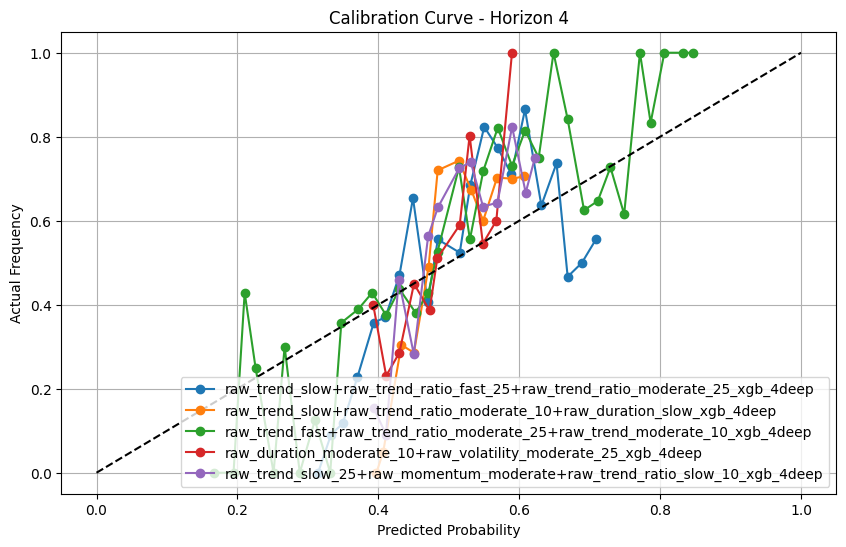

                                                                          model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn  fn
0  raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25_xgb_4deep      290      210   71.1%   61.0%  189  77  119  76
1        raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow_xgb_4deep      290      210   68.0%   62.0%  181  85   98  60
2    raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10_xgb_4deep      290      210   75.4%   66.3%  208  68  136  69
3                 raw_duration_moderate_10+raw_volatility_moderate_25_xgb_4deep      290      210   68.0%   58.9%  157  74  106  74
4     raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10_xgb_4deep      290      210   69.2%   60.1%  189  84  107  71
 


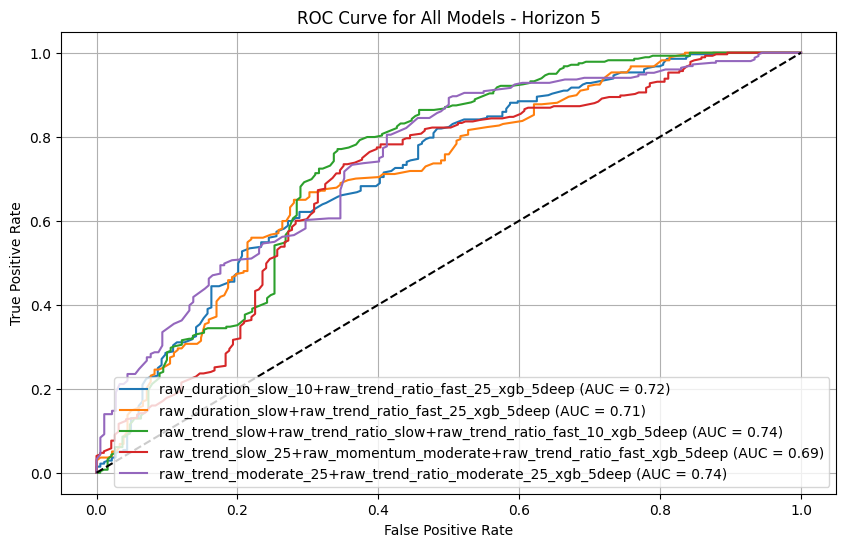

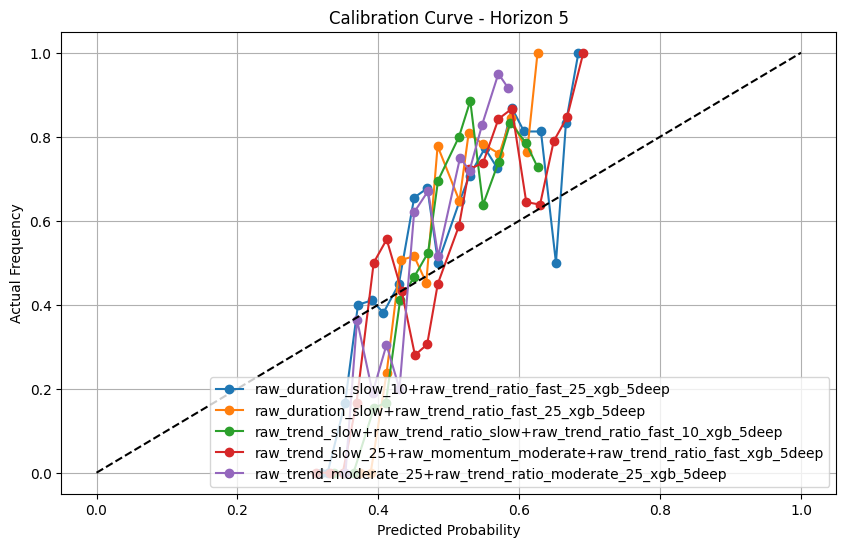

                                                                    model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn   fn
0                  raw_duration_slow_10+raw_trend_ratio_fast_25_xgb_5deep      298      202   75.8%   55.1%  172  55  129  105
1                     raw_duration_slow+raw_trend_ratio_fast_25_xgb_5deep      298      202   77.7%   53.3%  157  45  137  120
2   raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10_xgb_5deep      298      202   77.1%   62.1%  199  59  131   80
3  raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast_xgb_5deep      298      202   73.4%   64.8%  213  77  114   62
4             raw_trend_moderate_25+raw_trend_ratio_moderate_25_xgb_5deep      298      202   79.5%   54.2%  124  32  150  127
 


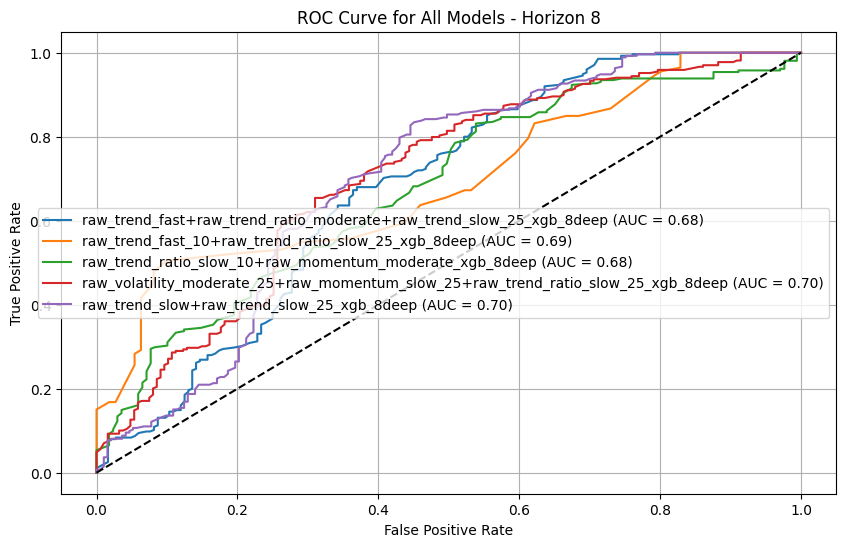

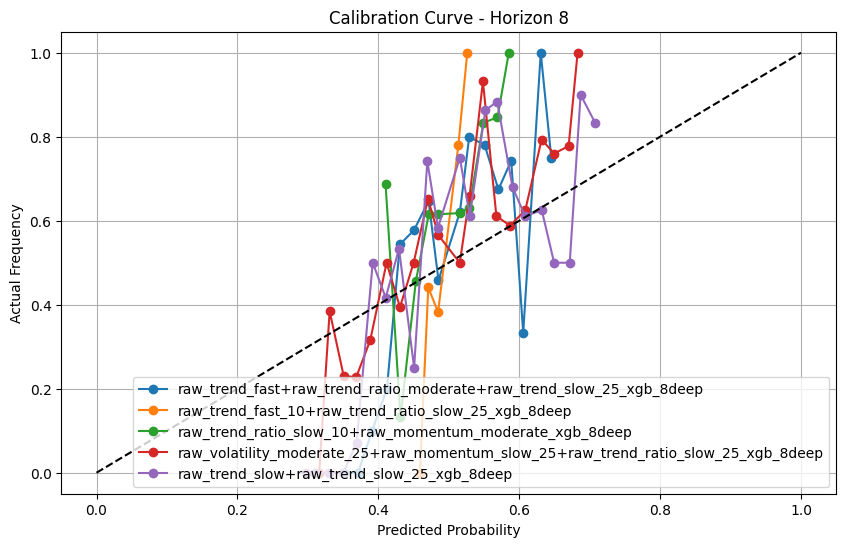

                                                                               model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn   fn
0                raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25_xgb_8deep      299      201   72.2%   56.0%  187  72  112   88
1                                raw_trend_fast_10+raw_trend_ratio_slow_25_xgb_8deep      299      201   85.7%   59.4%   42   7  104   71
2                            raw_trend_ratio_slow_10+raw_momentum_moderate_xgb_8deep      299      201   71.7%   49.3%  147  58  111  114
3  raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25_xgb_8deep      299      201   72.5%   58.6%  187  71  116   82
4                                         raw_trend_slow+raw_trend_slow_25_xgb_8deep      299      201   73.4%   60.2%  190  69  124   82
 


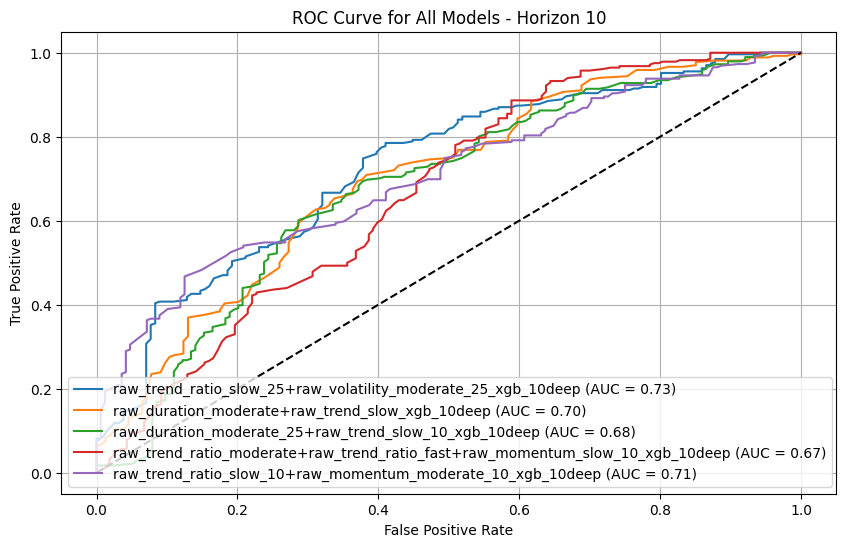

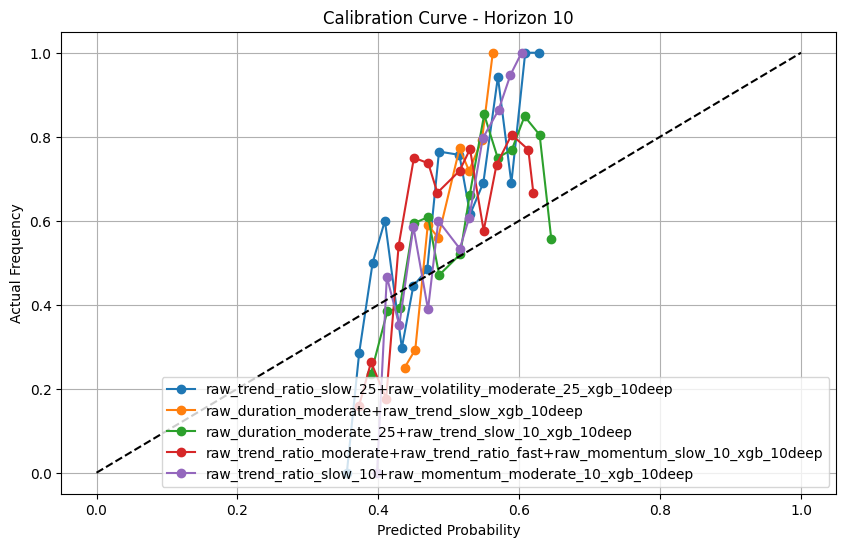

                                                                           model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn  fn
0                  raw_trend_ratio_slow_25+raw_volatility_moderate_25_xgb_10deep      320      180   76.9%   53.1%  180  54  102  90
1                                raw_duration_moderate+raw_trend_slow_xgb_10deep      320      180   77.1%   51.8%  172  51  103  96
2                          raw_duration_moderate_25+raw_trend_slow_10_xgb_10deep      320      180   74.2%   52.3%  207  72   92  84
3  raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10_xgb_10deep      320      180   72.1%   54.1%  214  83   80  68
4                    raw_trend_ratio_slow_10+raw_momentum_moderate_10_xgb_10deep      320      180   71.5%   53.5%  173  69   99  86
 


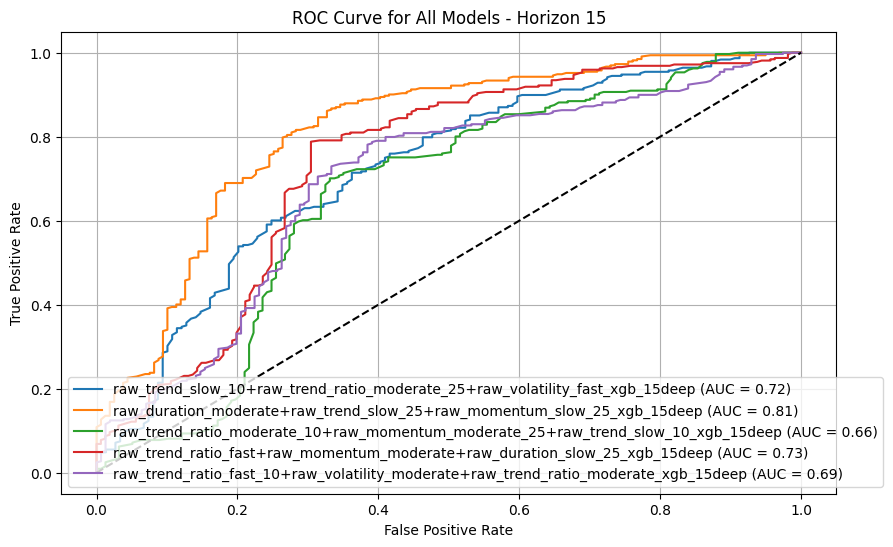

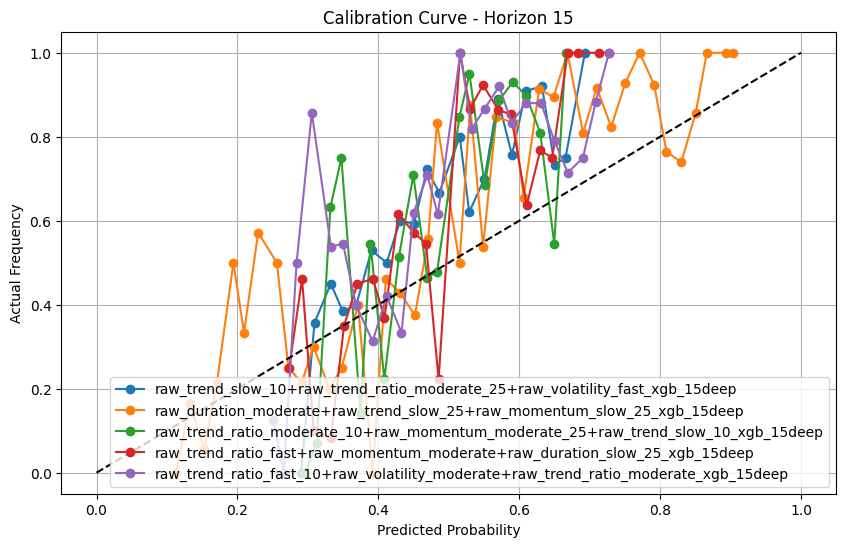

                                                                                 model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn   fn
0         raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast_xgb_15deep      339      161   80.1%   50.3%  213  53   96   95
1              raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25_xgb_15deep      339      161   84.4%   68.2%  282  52  107   50
2    raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10_xgb_15deep      339      161   81.2%   52.0%  224  52  105   97
3           raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25_xgb_15deep      339      161   83.7%   61.9%  252  49  112   69
4  raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate_xgb_15deep      339      161   82.8%   51.4%  226  47  109  103
 


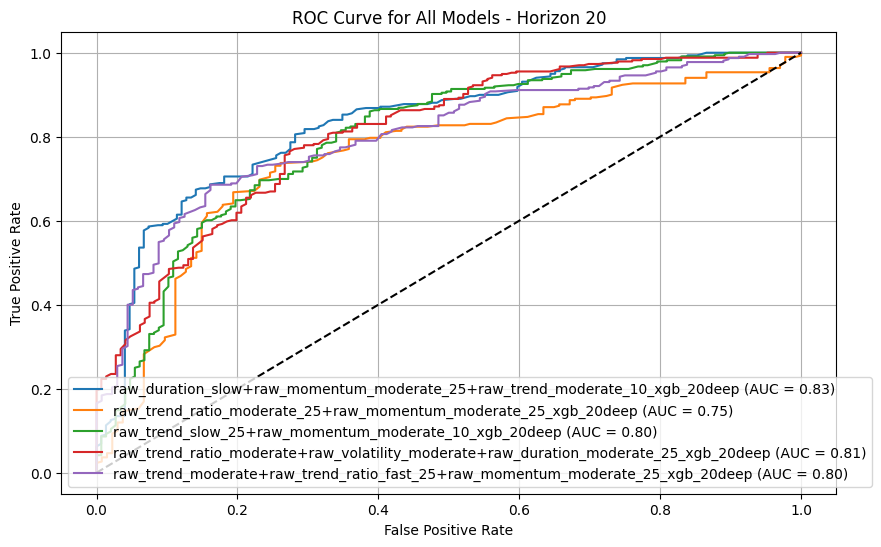

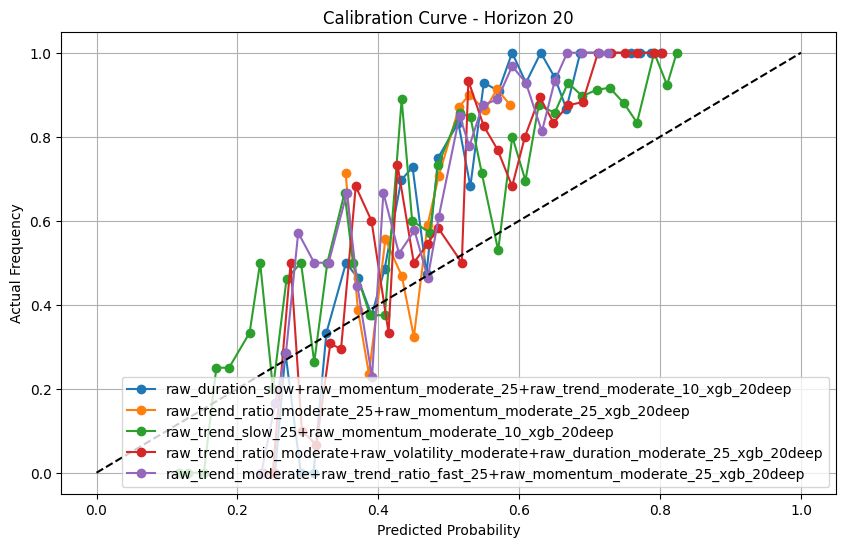

                                                                                  model  act_pos  act_neg pos_acc neg_acc   tp  fp   tn   fn
0           raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10_xgb_20deep      347      153   91.6%   53.7%  207  19  130  112
1                       raw_trend_ratio_moderate_25+raw_momentum_moderate_25_xgb_20deep      347      153   88.9%   50.2%  192  24  110  109
2                                 raw_trend_slow_25+raw_momentum_moderate_10_xgb_20deep      347      153   84.8%   57.5%  262  47  100   74
3  raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25_xgb_20deep      347      153   85.8%   57.5%  260  43  103   76
4        raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25_xgb_20deep      347      153   90.4%   53.3%  216  23  113   99
 


In [390]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)

for h in horizons:
    df = horizon_dfs[h].sort_values('Date', ascending=False).iloc[h:h+500, :].copy()
    
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        if f'_xgb_{h}' in col: #sum_{h}
            filtered = df[df[col] != 0]
            probs = filtered[col].apply(convert_signed_to_prob)
            targets = filtered[f'Return_{h}']
            fpr, tpr, _ = roc_curve(targets, probs)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{col} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve for All Models - Horizon {h}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()
    
    # --- Calibration Curve ---
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        if f'_xgb_{h}' in col:
            filtered = df[df[col] != 0]
            probs = filtered[col].apply(convert_signed_to_prob)
            targets = filtered[f'Return_{h}']
            prob_true, prob_pred = calibration_curve(targets, probs, n_bins=50)
            plt.plot(prob_pred, prob_true, marker='o', label=col)

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration Curve - Horizon {h}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Actual Frequency')
    plt.legend()
    plt.grid()
    plt.show()
    

    for arch in ['deep']:
        records = []
        actual_pos = df[f'Return_{h}'].sum()
        actual_neg = len(df[f'Return_{h}']) - actual_pos
        for col in df.columns:
            if f'_xgb_{h}{arch}' in col:
                # only keep the rows that actually got a prediction
                filtered = df[df[col] != 0]
                # convert your raw score to a probability
                probs = filtered[col].apply(convert_signed_to_prob)
                # binarize at 0.5
                y_pred = (probs >= 0.5).astype(int)
                y_true = filtered[f'Return_{h}']
                
                # compute the matrix
                cm = confusion_matrix(y_true, y_pred,labels=[0,1])
                tn, fp, fn, tp = cm.ravel()
                records.append({
                    'model': col,
                    'act_pos': actual_pos,
                    'act_neg': actual_neg,
                    'pos_acc': f"{(tp/(tp + fp)):.1%}" if actual_pos>0 else "n/a",
                    'neg_acc': f"{(tn/(tn + fn)):.1%}" if actual_neg>0 else "n/a",
                    'tp': tp,
                    'fp': fp,
                    'tn': tn,
                    'fn': fn,
                })

        # make your summary table
        cm_df = pd.DataFrame(records)
        print(cm_df.to_string())
        print(' ')